# Atelier Seaborn — Analyse exploratoire des données IoT

Ce notebook réalise une analyse exploratoire du dataset de capteurs IoT (température, humidité, pression, consommation, état) à l'aide de **Seaborn**, en s'appuyant sur NumPy, Pandas et Matplotlib.

## Étape 4 — Import des librairies

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

EXPORT_DIR = "../exports"
import os
os.makedirs(EXPORT_DIR, exist_ok=True)


Étape 5 — Import du dataset dans df



In [9]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Étape 6 — Vérification du contenu du dataframe

In [10]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [11]:
df.describe(include="all")

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
count,605,605,605,605,599.000000,600.00000,600.000000,600.000000,601
unique,600,600,12,4,NaN,NaN,NaN,NaN,3
top,M0026,2026-01-06 01:00:00,C002,B001,NaN,NaN,NaN,NaN,OK
freq,2,2,52,153,NaN,NaN,NaN,NaN,567
mean,NaN,NaN,NaN,NaN,24.878314,64.92620,1012.221900,208.675417,NaN
std,NaN,NaN,NaN,NaN,4.059576,10.76905,10.599042,72.243567,NaN
min,NaN,NaN,NaN,NaN,-18.500000,28.52000,850.000000,18.120000,NaN
25%,NaN,NaN,NaN,NaN,22.570000,58.17250,1006.790000,160.177500,NaN
50%,NaN,NaN,NaN,NaN,24.860000,65.37500,1012.855000,206.150000,NaN
75%,NaN,NaN,NaN,NaN,27.275000,71.61500,1017.827500,254.127500,NaN


In [12]:
# Valeurs manquantes
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

**Constat :** le dataset contient 605 lignes et 9 colonnes. On observe quelques valeurs manquantes (température, humidité, pression, consommation, état) qu'il faudra garder à l'esprit pour la suite (Seaborn ignore les NaN par défaut dans la plupart des fonctions de distribution).

## Partie 1 — Distribution d'une variable avec `histplot()`

### 1) Distribution des températures

1.   Élément de liste
2.   Élément de liste



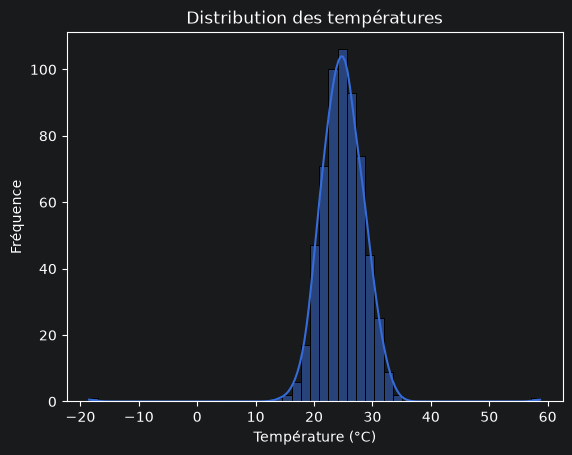

In [13]:
plt.figure()
sns.histplot(data=df, x="temperature", kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

In [14]:
print(df["temperature"].median(), df["temperature"].mean())

24.86 24.87831385642738


### 2) Autour de quelle valeur les températures sont concentrées ?

Les températures sont concentrées **autour de 24-25 °C** (médiane ≈ 24,86 °C, moyenne ≈ 24,88 °C), ce qui correspond au pic principal de l'histogramme.

### 3) La distribution semble-t-elle symétrique ?

Globalement **oui**, la distribution est assez symétrique et proche d'une loi normale autour de 25 °C, avec une légère traîne vers les valeurs basses et hautes due aux valeurs extrêmes.

### 4) Existe-t-il des valeurs extrêmes ?

**Oui.** On observe des valeurs très éloignées de la masse principale : un minimum proche de **-18,5 °C** et un maximum proche de **58,7 °C**, largement en dehors de la plage physiquement plausible pour une pièce/bâtiment — probablement des erreurs de capteur (à confirmer avec la colonne `etat`).

### 5) Modifier le nombre de classes (bins)

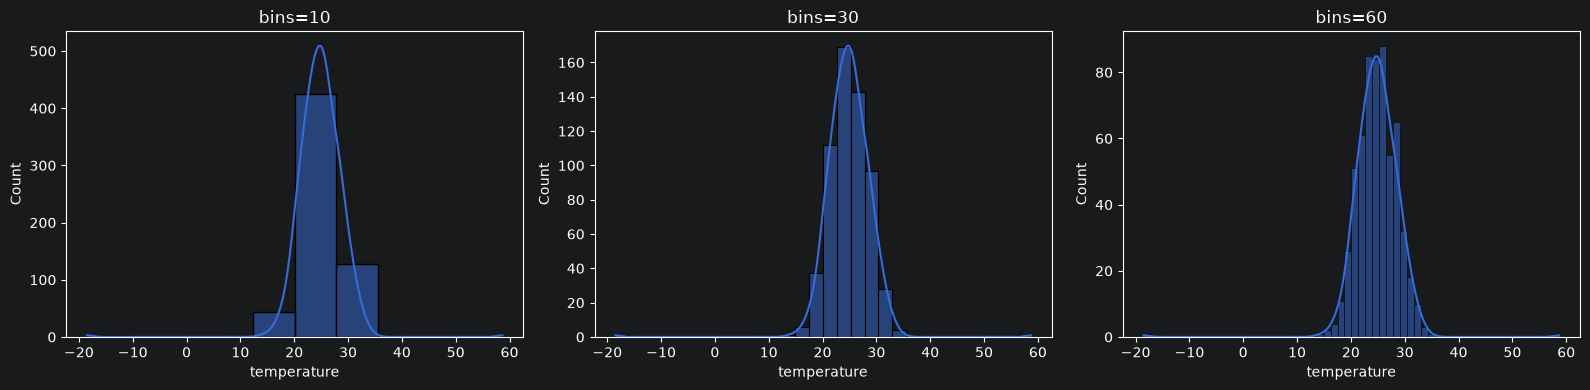

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=b, kde=True, ax=ax)
    ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

Avec **peu de classes (10)**, la distribution paraît lisse mais on perd du détail. Avec **beaucoup de classes (60)**, on distingue mieux les valeurs extrêmes isolées mais le graphique devient plus 'bruité'. Un compromis autour de **30 classes** donne une lecture claire de la forme générale tout en distinguant les outliers.

### 6) Distribution des températures par bâtiment

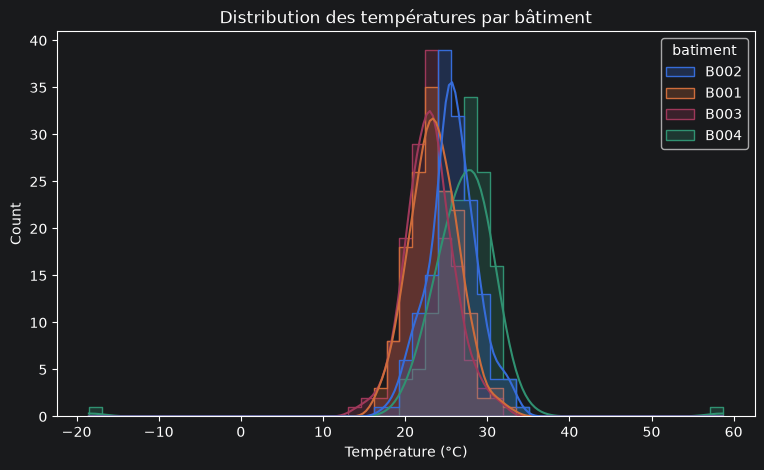

In [16]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

On voit que les bâtiments n'ont pas exactement la même distribution : **B004** semble avoir les températures les plus dispersées (et contient les valeurs les plus extrêmes), tandis que B001/B002/B003 sont plus resserrés autour de leur moyenne.